# QCBM for Credit Spread Tail Risk Scenario Generation

**Author:** [qubit-lab.ch](https://qubit-lab.ch)

**Copyright:** © 2026 qubit-lab.ch. All rights reserved.  
For legal information and terms of use, see **[qubit-lab.ch/legal](https://qubit-lab.ch/legal)**.

This notebook presents a simulator-based proof of concept for learning and sampling a discretized empirical credit copula with a Quantum Circuit Born Machine (QCBM).

We use daily FRED credit spread index data for:
- BBB option-adjusted spread (OAS)
- BB option-adjusted spread (OAS)
- broad high-yield option-adjusted spread (OAS)

The workflow is:

1. Load daily credit spread index levels and convert them to daily spread changes  
2. Transform each marginal into pseudo-observations via empirical ranks  
3. Discretize the joint dependence structure on an 8 x 8 x 8 copula grid  
4. Train QCBMs to learn:
   - the full empirical copula distribution
   - the non-stress conditional distribution
   - the stress conditional distribution  
5. Recombine the conditional models into a regime-mixture QCBM  
6. Compare the baseline and regime-mixture approaches with a focus on upper-tail stress states  

The objective is not to claim production readiness or quantum advantage from this notebook alone.  
The goal is to illustrate how QCBMs can act as dependency-aware scenario generators for credit tail-risk analysis.

For an accompanying explanatory video and additional notebooks and videos on quantum computing in finance, see **[qubit-lab.ch](https://qubit-lab.ch)**.

**Implementation summary**
- Framework: PennyLane
- Backend: `default.qubit`
- Assets: 3
- Bins per asset: 8
- Qubits per asset: 3
- Total qubits: 9
- Sampling shots for scenario generation: 20,000

## Notebook roadmap

1. Install packages and define global settings  
2. Load FRED data and construct the empirical copula distribution  
3. Define the QCBM ansatz and loss functions  
4. Train the baseline and regime-specific QCBMs  
5. Compare fit quality, tail probabilities and sampled scenarios  
6. Visualize the learned distributions and summarize the findings


In [ ]:
# Section 1: Install packages

!pip install pennylane pandas numpy matplotlib scipy pandas_datareader

In [ ]:
# Section 2: Imports and global configuration

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

from scipy.stats import rankdata, spearmanr, kendalltau
from pandas_datareader import data as web

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

In [ ]:
# Section 2.1: Data settings

FRED_SERIES = {
    "BBB_OAS": "BAMLC0A4CBBB",
    "BB_OAS":  "BAMLH0A1HYBB",
    "HY_OAS":  "BAMLH0A0HYM2",
}

START_DATE = "2000-01-01"
END_DATE   = "2025-12-31"

In [ ]:
# Section 2.2: Copula and discretization settings

N_ASSETS = 3
N_QUBITS_PER_ASSET = 3

# 3 qubits per asset imply 8 representable levels
PHYSICAL_LEVELS_PER_ASSET = 2 ** N_QUBITS_PER_ASSET   # 8

# Use a fully aligned 8-bin discretization
N_ACTIVE_BINS_PER_ASSET = PHYSICAL_LEVELS_PER_ASSET   # 8

TOTAL_QUBITS = N_ASSETS * N_QUBITS_PER_ASSET          # 9
N_QCBM_STATES = PHYSICAL_LEVELS_PER_ASSET ** N_ASSETS # 512
N_ACTIVE_STATES = N_ACTIVE_BINS_PER_ASSET ** N_ASSETS # 512

In [ ]:
# Section 2.3: Stress-region settings

STRICT_STRESS_BIN = N_ACTIVE_BINS_PER_ASSET - 1       # 7
BROAD_STRESS_MIN_BIN = N_ACTIVE_BINS_PER_ASSET - 2    # 6
CONDITIONAL_STRESS_MIN_BIN = BROAD_STRESS_MIN_BIN     # bins 6 and 7 define the stress corner

In [ ]:
# Section 2.4: QCBM training settings

SAMPLE_SHOTS = 20000
RANDOM_SEED = 42
BEST_SEED = 42

TRAIN_LR_PHASES = [
    (400, 0.02),
    (400, 0.01),
    (400, 0.005),
    (400, 0.003),
    (400, 0.001),
    (500, 0.001),
    (500, 0.0005),
]

# Keep circuit depth fixed across models for comparability
N_CUSTOM_LAYERS = 6

np.random.seed(RANDOM_SEED)

print("Configuration")
print("=============")
print(f"Assets:                      {N_ASSETS}")
print(f"Qubits per asset:            {N_QUBITS_PER_ASSET}")
print(f"Total qubits:                {TOTAL_QUBITS}")
print(f"Bins per asset:              {N_ACTIVE_BINS_PER_ASSET}")
print(f"Active empirical states:     {N_ACTIVE_STATES}")
print(f"Physical QCBM states:        {N_QCBM_STATES}")
print(f"Strict stress bin:           {STRICT_STRESS_BIN}")
print(f"Broad stress min bin:        {BROAD_STRESS_MIN_BIN}")
print(f"Sampling shots:              {SAMPLE_SHOTS}")
print(f"Custom circuit layers:       {N_CUSTOM_LAYERS}")

Configuration
Assets:                      3
Qubits per asset:            3
Total qubits:                9
Bins per asset:              8
Active empirical states:     512
Physical QCBM states:        512
Strict stress bin:           7
Broad stress min bin:        6
Sampling shots:              20000
Custom circuit layers:       6


## Data loading and empirical copula construction

We now load the three credit spread series, convert levels into daily changes, transform each marginal into pseudo-observations, and build the discretized empirical copula distribution on an 8 x 8 x 8 grid.

In [ ]:
# Section 3: Helper functions for data loading and copula construction

def load_fred_series(series_map, start_date, end_date):
    frames = []
    for label, fred_code in series_map.items():
        s = web.DataReader(fred_code, "fred", start_date, end_date)
        s.columns = [label]
        frames.append(s)
    df = pd.concat(frames, axis=1).dropna().copy()
    return df


def to_pseudo_obs(x):
    x = np.asarray(x)
    return rankdata(x, method="average") / (len(x) + 1)


def discretize_pseudo_obs(u, n_bins_active):
    idx = np.floor(u * n_bins_active).astype(int)
    return np.clip(idx, 0, n_bins_active - 1)


def multiindex_to_state_index(bin_df, base_dim):
    arr = bin_df.to_numpy().astype(int)
    state_idx = (
        arr[:, 0] * (base_dim ** 2) +
        arr[:, 1] * (base_dim ** 1) +
        arr[:, 2]
    )
    return state_idx.astype(int)


def state_index_to_triplet(idx, base_dim):
    b1 = idx // (base_dim ** 2)
    rem = idx % (base_dim ** 2)
    b2 = rem // base_dim
    b3 = rem % base_dim
    return b1, b2, b3


def probs_to_cube(prob_vec, base_dim):
    return np.asarray(prob_vec).reshape(base_dim, base_dim, base_dim)


def stress_probability_corner(prob_vec, base_dim, active_bins, min_bin):
    cube = probs_to_cube(prob_vec, base_dim)
    return cube[min_bin:active_bins, min_bin:active_bins, min_bin:active_bins].sum()


def invalid_state_mass(prob_vec, base_dim, active_bins):
    cube = probs_to_cube(prob_vec, base_dim)
    valid_mass = cube[:active_bins, :active_bins, :active_bins].sum()
    return 1.0 - valid_mass


def js_divergence(p, q, eps=1e-12):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    q = np.clip(np.asarray(q, dtype=float), eps, 1.0)
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * (kl_pm + kl_qm)


def build_empirical_copula_states(df_levels, n_bins_active, base_dim):
    df = df_levels.diff().dropna().copy()

    pseudo = pd.DataFrame(index=df.index)
    bins = pd.DataFrame(index=df.index)

    for col in df.columns:
        pseudo[col] = to_pseudo_obs(df[col].values)
        bins[col] = discretize_pseudo_obs(pseudo[col].values, n_bins_active)

    state_idx = multiindex_to_state_index(bins, base_dim)
    counts = np.bincount(state_idx, minlength=base_dim ** df.shape[1]).astype(float)
    probs = counts / counts.sum()

    return df, pseudo, bins, state_idx, probs


def build_regime_distribution(bins_df, base_dim, min_bin, regime="stress"):
    stress_mask = (
        (bins_df.iloc[:, 0] >= min_bin) &
        (bins_df.iloc[:, 1] >= min_bin) &
        (bins_df.iloc[:, 2] >= min_bin)
    )

    if regime == "stress":
        mask = stress_mask
    elif regime == "nonstress":
        mask = ~stress_mask
    else:
        raise ValueError("regime must be 'stress' or 'nonstress'")

    sub_bins = bins_df.loc[mask].copy()
    sub_state_idx = multiindex_to_state_index(sub_bins, base_dim)
    counts = np.bincount(sub_state_idx, minlength=base_dim ** bins_df.shape[1]).astype(float)

    if counts.sum() == 0:
        raise ValueError(f"No observations found for regime='{regime}'.")

    probs = counts / counts.sum()
    return mask, sub_bins, sub_state_idx, probs


def summarize_dataset(name, df_changes, probs, base_dim, active_bins, n_obs):
    print(f"=== {name} ===")
    print(f"Observations:                  {n_obs:,}")
    print(f"Active state space:            {active_bins ** 3}")
    print(f"Physical QCBM state space:     {base_dim ** 3}")
    print(f"Average obs / active state:    {n_obs / (active_bins ** 3):.2f}")
    print()

    print("Pairwise correlations on daily spread changes")
    print(df_changes.corr())
    print()

    print("Pairwise rank dependence")
    for c1 in df_changes.columns:
        for c2 in df_changes.columns:
            if c1 < c2:
                rho = spearmanr(df_changes[c1], df_changes[c2]).statistic
                tau = kendalltau(df_changes[c1], df_changes[c2]).statistic
                print(f"{c1} vs {c2}: Spearman={rho:.4f}, Kendall={tau:.4f}")
    print()

    strict = stress_probability_corner(probs, base_dim, active_bins, STRICT_STRESS_BIN)
    broad = stress_probability_corner(probs, base_dim, active_bins, BROAD_STRESS_MIN_BIN)
    invalid = invalid_state_mass(probs, base_dim, active_bins)

    print(f"Strict stress probability ({STRICT_STRESS_BIN},{STRICT_STRESS_BIN},{STRICT_STRESS_BIN}): {strict:.6f}")
    print(f"Broad stress probability ({BROAD_STRESS_MIN_BIN}-{STRICT_STRESS_BIN} corner): {broad:.6f}")
    print(f"Invalid-state mass:            {invalid:.6f}")
    print()

    top_states = pd.Series(probs).sort_values(ascending=False).head(12)
    top_rows = []
    for idx, p in top_states.items():
        b1, b2, b3 = state_index_to_triplet(int(idx), base_dim)
        top_rows.append([idx, b1, b2, b3, p])

    top_df = pd.DataFrame(
        top_rows,
        columns=["state", "BBB_bin", "BB_bin", "HY_bin", "probability"]
    )
    display(top_df)

In [ ]:
# Section 3.1: Load the data and build empirical targets

df_levels = load_fred_series(FRED_SERIES, START_DATE, END_DATE)

df_changes, df_pseudo, df_bins, full_state_idx, empirical_probs = build_empirical_copula_states(
    df_levels,
    N_ACTIVE_BINS_PER_ASSET,
    PHYSICAL_LEVELS_PER_ASSET
)

stress_mask, stress_bins, stress_state_idx, stress_probs = build_regime_distribution(
    df_bins,
    PHYSICAL_LEVELS_PER_ASSET,
    min_bin=CONDITIONAL_STRESS_MIN_BIN,
    regime="stress"
)

nonstress_mask, nonstress_bins, nonstress_state_idx, nonstress_probs = build_regime_distribution(
    df_bins,
    PHYSICAL_LEVELS_PER_ASSET,
    min_bin=CONDITIONAL_STRESS_MIN_BIN,
    regime="nonstress"
)

PI_STRESS = len(stress_state_idx) / len(full_state_idx)
PI_NONSTRESS = 1.0 - PI_STRESS

# Exact empirical reconstruction from the two conditional empirical distributions
empirical_reconstructed = PI_NONSTRESS * nonstress_probs + PI_STRESS * stress_probs
empirical_reconstruction_js = js_divergence(empirical_probs, empirical_reconstructed)

print("Shapes and regime split")
print("=======================")
print("Levels shape:         ", df_levels.shape)
print("Changes shape:        ", df_changes.shape)
print("Full observations:    ", len(full_state_idx))
print("Non-stress obs:       ", len(nonstress_state_idx))
print("Stress obs:           ", len(stress_state_idx))
print("Stress frequency pi:  ", round(PI_STRESS, 6))
print("Reconstruction JS:    ", empirical_reconstruction_js)
print()

display(df_levels.tail())
display(df_changes.tail())

Shapes and regime split
Levels shape:          (6788, 3)
Changes shape:         (6787, 3)
Full observations:     6787
Non-stress obs:        5769
Stress obs:            1018
Stress frequency pi:   0.149993
Reconstruction JS:     4.498472546127383e-19



,BBB_OAS,BB_OAS,HY_OAS
DATE,,,
2025-12-24,1.00,1.72,2.84
2025-12-26,1.00,1.73,2.86
2025-12-29,1.00,1.74,2.87
2025-12-30,1.01,1.71,2.84
2025-12-31,1.01,1.69,2.81


,BBB_OAS,BB_OAS,HY_OAS
DATE,,,
2025-12-24,-0.01,0.02,0.01
2025-12-26,0.00,0.01,0.02
2025-12-29,0.00,0.01,0.01
2025-12-30,0.01,-0.03,-0.03
2025-12-31,0.00,-0.02,-0.03


In [ ]:
# Section 3.2: Summarize the empirical datasets

summarize_dataset(
    "Full empirical copula target",
    df_changes,
    empirical_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    len(full_state_idx)
)

summarize_dataset(
    "Non-stress conditional target",
    df_changes.loc[nonstress_mask],
    nonstress_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    len(nonstress_state_idx)
)

summarize_dataset(
    "Stress conditional target",
    df_changes.loc[stress_mask],
    stress_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    len(stress_state_idx)
)

=== Full empirical copula target ===
Observations:                  6,787
Active state space:            512
Physical QCBM state space:     512
Average obs / active state:    13.26

Pairwise correlations on daily spread changes
          BBB_OAS    BB_OAS    HY_OAS
BBB_OAS  1.000000  0.589075  0.661049
BB_OAS   0.589075  1.000000  0.895278
HY_OAS   0.661049  0.895278  1.000000

Pairwise rank dependence
BBB_OAS vs BB_OAS: Spearman=0.6194, Kendall=0.4938
BBB_OAS vs HY_OAS: Spearman=0.6375, Kendall=0.5082
BB_OAS vs HY_OAS: Spearman=0.9360, Kendall=0.8384

Strict stress probability (7,7,7): 0.068661
Broad stress probability (6-7 corner): 0.149993
Invalid-state mass:            0.000000



,state,BBB_bin,BB_bin,HY_bin,probability
0,511,7,7,7,0.068661
1,0,0,0,0,0.064093
2,292,4,4,4,0.053927
3,137,2,1,1,0.035656
4,274,4,2,2,0.030352
5,301,4,5,5,0.027700
6,438,6,6,6,0.027258
7,310,4,6,6,0.024459
8,283,4,3,3,0.022690
9,265,4,1,1,0.022543


=== Non-stress conditional target ===
Observations:                  5,769
Active state space:            512
Physical QCBM state space:     512
Average obs / active state:    11.27

Pairwise correlations on daily spread changes
          BBB_OAS    BB_OAS    HY_OAS
BBB_OAS  1.000000  0.306370  0.430954
BB_OAS   0.306370  1.000000  0.805352
HY_OAS   0.430954  0.805352  1.000000

Pairwise rank dependence
BBB_OAS vs BB_OAS: Spearman=0.4470, Kendall=0.3460
BBB_OAS vs HY_OAS: Spearman=0.4719, Kendall=0.3658
BB_OAS vs HY_OAS: Spearman=0.9069, Kendall=0.7976

Strict stress probability (7,7,7): 0.000000
Broad stress probability (6-7 corner): 0.000000
Invalid-state mass:            0.000000



,state,BBB_bin,BB_bin,HY_bin,probability
0,0,0,0,0,0.075403
1,292,4,4,4,0.063443
2,137,2,1,1,0.041948
3,274,4,2,2,0.035708
4,301,4,5,5,0.032588
5,310,4,6,6,0.028774
6,283,4,3,3,0.026694
7,265,4,1,1,0.026521
8,9,0,1,1,0.024788
9,146,2,2,2,0.023748


=== Stress conditional target ===
Observations:                  1,018
Active state space:            512
Physical QCBM state space:     512
Average obs / active state:    1.99

Pairwise correlations on daily spread changes
          BBB_OAS    BB_OAS    HY_OAS
BBB_OAS  1.000000  0.756443  0.760281
BB_OAS   0.756443  1.000000  0.961073
HY_OAS   0.760281  0.961073  1.000000

Pairwise rank dependence
BBB_OAS vs BB_OAS: Spearman=0.5823, Kendall=0.4467
BBB_OAS vs HY_OAS: Spearman=0.5977, Kendall=0.4604
BB_OAS vs HY_OAS: Spearman=0.8969, Kendall=0.7577

Strict stress probability (7,7,7): 0.457760
Broad stress probability (6-7 corner): 1.000000
Invalid-state mass:            0.000000



,state,BBB_bin,BB_bin,HY_bin,probability
0,511,7,7,7,0.457760
1,438,6,6,6,0.181729
2,447,6,7,7,0.114931
3,502,7,6,6,0.108055
4,510,7,7,6,0.048134
5,446,6,7,6,0.042240
6,503,7,6,7,0.032417
7,439,6,6,7,0.014735
8,333,5,1,5,0.000000
9,335,5,1,7,0.000000


## QCBM definition

We now define the quantum devices, the custom structured ansatz, and the KL-based training objective used to fit the model distribution to the empirical copula distribution.

In [ ]:
# Section 4: QCBM devices and circuit structure

dev_probs = qml.device("default.qubit", wires=TOTAL_QUBITS)
dev_samples = qml.device("default.qubit", wires=TOTAL_QUBITS, shots=SAMPLE_SHOTS)

wires = list(range(TOTAL_QUBITS))

ASSET_BLOCKS = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8],
]

CROSS_LINKS = [
    (0, 3), (3, 6),
    (1, 4), (4, 7),
    (2, 5), (5, 8),
]

CROSS_LINKS_2 = [
    (0, 4), (3, 7), (1, 5), (4, 8)
]

In [ ]:
# Section 4.1: Custom structured ansatz

def custom_asset_structured_ansatz(params):
    """
    Custom structured QCBM ansatz.

    params shape: (N_CUSTOM_LAYERS, 5, TOTAL_QUBITS)

    Channels:
      0 -> within-layer RY
      1 -> within-layer RZ
      2 -> post intra-block RY
      3 -> post cross-block RZ
      4 -> final per-layer RY
    """
    for w in wires:
        qml.Hadamard(wires=w)

    for layer in range(N_CUSTOM_LAYERS):
        for w in wires:
            qml.RY(params[layer, 0, w], wires=w)
            qml.RZ(params[layer, 1, w], wires=w)

        # Intra-asset entanglement
        for block in ASSET_BLOCKS:
            qml.CNOT(wires=[block[0], block[1]])
            qml.CNOT(wires=[block[1], block[2]])
            qml.CNOT(wires=[block[2], block[0]])

        for w in wires:
            qml.RY(params[layer, 2, w], wires=w)

        # Cross-asset entanglement
        for c, t in CROSS_LINKS:
            qml.CNOT(wires=[c, t])

        for c, t in CROSS_LINKS_2:
            qml.CNOT(wires=[c, t])

        for w in wires:
            qml.RZ(params[layer, 3, w], wires=w)
            qml.RY(params[layer, 4, w], wires=w)

In [ ]:
# Section 4.2: QNodes and loss functions

@qml.qnode(dev_probs, interface="autograd")
def qcbm_probs(weights):
    custom_asset_structured_ansatz(weights)
    return qml.probs(wires=wires)


@qml.qnode(dev_samples, interface="autograd")
def qcbm_samples(weights):
    custom_asset_structured_ansatz(weights)
    return qml.sample(wires=wires)


def kl_loss(weights, target_probs, eps=1e-10):
    model_probs = qcbm_probs(weights)
    model_probs = pnp.clip(model_probs, eps, 1.0)
    target_probs_safe = pnp.clip(target_probs, eps, 1.0)
    return pnp.sum(target_probs_safe * pnp.log(target_probs_safe / model_probs))


shape = (N_CUSTOM_LAYERS, 5, TOTAL_QUBITS)

print("Parameter shape:", shape)
print("Qubits:", TOTAL_QUBITS)
print("Physical QCBM states:", N_QCBM_STATES)
print("Active empirical states:", N_ACTIVE_STATES)
print("Custom layers:", N_CUSTOM_LAYERS)
print("Ansatz: custom_asset_structured_ansatz")

Parameter shape: (6, 5, 9)
Qubits: 9
Physical QCBM states: 512
Active empirical states: 512
Custom layers: 6
Ansatz: custom_asset_structured_ansatz


## Model training

We train three models:
1. a baseline QCBM on the full empirical copula distribution
2. a non-stress conditional QCBM
3. a stress conditional QCBM

The second and third models are then recombined into a regime-mixture QCBM using the empirical stress frequency.

In [ ]:
# Section 5: Training utilities

def sample_model_distribution(weights, n_states, total_qubits):
    sample_bits = np.array(qcbm_samples(weights))
    powers = 2 ** np.arange(total_qubits - 1, -1, -1)
    sample_state_idx = sample_bits.dot(powers).astype(int)
    sample_counts = np.bincount(sample_state_idx, minlength=n_states).astype(float)
    sampled_probs = sample_counts / sample_counts.sum()
    return sampled_probs


def train_qcbm_model(model_name, target_probs_np, lr_phases, seed):
    target_probs = pnp.array(target_probs_np, requires_grad=False)
    loss_fn = lambda w: kl_loss(w, target_probs)

    rng = np.random.default_rng(seed)
    weights = pnp.array(
        rng.uniform(low=-0.4, high=0.4, size=shape),
        requires_grad=True
    )

    best_js = np.inf
    best_weights = None
    best_probs = None
    history = []

    total_epochs = sum(x[0] for x in lr_phases)
    epoch_counter = 0

    print(f"Training {model_name}")
    print(f"Total epochs: {total_epochs}")

    for n_epochs_phase, lr in lr_phases:
        opt = qml.AdamOptimizer(stepsize=lr)

        for _ in range(n_epochs_phase):
            epoch_counter += 1
            weights = opt.step(loss_fn, weights)

            if epoch_counter == 1 or epoch_counter % 50 == 0 or epoch_counter == total_epochs:
                model_probs_now = np.array(qcbm_probs(weights))
                loss_now = float(loss_fn(weights))
                js_now = js_divergence(target_probs_np, model_probs_now)
                strict_now = stress_probability_corner(
                    model_probs_now,
                    PHYSICAL_LEVELS_PER_ASSET,
                    N_ACTIVE_BINS_PER_ASSET,
                    STRICT_STRESS_BIN
                )
                broad_now = stress_probability_corner(
                    model_probs_now,
                    PHYSICAL_LEVELS_PER_ASSET,
                    N_ACTIVE_BINS_PER_ASSET,
                    BROAD_STRESS_MIN_BIN
                )
                invalid_now = invalid_state_mass(
                    model_probs_now,
                    PHYSICAL_LEVELS_PER_ASSET,
                    N_ACTIVE_BINS_PER_ASSET
                )

                history.append({
                    "model": model_name,
                    "epoch": epoch_counter,
                    "lr": lr,
                    "loss": loss_now,
                    "js_vs_target": js_now,
                    "strict_tail": strict_now,
                    "broad_tail": broad_now,
                    "invalid_mass": invalid_now
                })

                if js_now < best_js:
                    best_js = js_now
                    best_weights = weights.copy()
                    best_probs = model_probs_now.copy()

                print(
                    f"Epoch {epoch_counter:4d} | "
                    f"lr={lr:<7} | "
                    f"Loss={loss_now:.6f} | "
                    f"JS={js_now:.6f} | "
                    f"Strict={strict_now:.6f} | "
                    f"Broad={broad_now:.6f} | "
                    f"Invalid={invalid_now:.6f}"
                )

    sampled_probs = sample_model_distribution(best_weights, N_QCBM_STATES, TOTAL_QUBITS)

    return {
        "model_name": model_name,
        "best_weights": best_weights,
        "exact_probs": best_probs,
        "sampled_probs": sampled_probs,
        "history_df": pd.DataFrame(history),
        "best_js_vs_target": best_js
    }

In [ ]:
# Section 5.1: Train the baseline and regime-specific QCBMs

full_model = train_qcbm_model(
    model_name="Baseline: full empirical copula",
    target_probs_np=empirical_probs,
    lr_phases=TRAIN_LR_PHASES,
    seed=BEST_SEED
)

nonstress_model = train_qcbm_model(
    model_name="Model A: non-stress conditional copula",
    target_probs_np=nonstress_probs,
    lr_phases=TRAIN_LR_PHASES,
    seed=BEST_SEED
)

stress_model = train_qcbm_model(
    model_name="Model B: stress conditional copula",
    target_probs_np=stress_probs,
    lr_phases=TRAIN_LR_PHASES,
    seed=BEST_SEED
)

Training Baseline: full empirical copula
Total epochs: 3000
Epoch    1 | lr=0.02    | Loss=2.183703 | JS=0.399845 | Strict=0.000407 | Broad=0.011988 | Invalid=0.000000
Epoch   50 | lr=0.02    | Loss=0.499102 | JS=0.144555 | Strict=0.030171 | Broad=0.079537 | Invalid=0.000000
Epoch  100 | lr=0.02    | Loss=0.352467 | JS=0.104470 | Strict=0.035542 | Broad=0.085382 | Invalid=0.000000
Epoch  150 | lr=0.02    | Loss=0.283003 | JS=0.084302 | Strict=0.040919 | Broad=0.087419 | Invalid=0.000000
Epoch  200 | lr=0.02    | Loss=0.212566 | JS=0.063721 | Strict=0.045318 | Broad=0.101654 | Invalid=0.000000
Epoch  250 | lr=0.02    | Loss=0.173460 | JS=0.051847 | Strict=0.043656 | Broad=0.105191 | Invalid=0.000000
Epoch  300 | lr=0.02    | Loss=0.144515 | JS=0.043173 | Strict=0.042612 | Broad=0.107932 | Invalid=0.000000
Epoch  350 | lr=0.02    | Loss=0.124686 | JS=0.036941 | Strict=0.044614 | Broad=0.112541 | Invalid=0.000000
Epoch  400 | lr=0.02    | Loss=0.111613 | JS=0.033215 | Strict=0.049498 | Br

In [ ]:
# Section 5.2: Build the regime-mixture reconstruction

mixture_exact_probs = PI_NONSTRESS * nonstress_model["exact_probs"] + PI_STRESS * stress_model["exact_probs"]
mixture_sampled_probs = PI_NONSTRESS * nonstress_model["sampled_probs"] + PI_STRESS * stress_model["sampled_probs"]

history_df = pd.concat(
    [
        full_model["history_df"],
        nonstress_model["history_df"],
        stress_model["history_df"],
    ],
    ignore_index=True
)

print("Mixture weights")
print("===============")
print(f"pi_nonstress = {PI_NONSTRESS:.6f}")
print(f"pi_stress    = {PI_STRESS:.6f}")
print()

display(history_df.tail(15))

Mixture weights
pi_nonstress = 0.850007
pi_stress    = 0.149993



,model,epoch,lr,loss,js_vs_target,strict_tail,broad_tail,invalid_mass
168,Model B: stress conditional copula,2300,0.0010,1.725193e-07,6.804224e-08,0.457728,1.0,1.776357e-15
169,Model B: stress conditional copula,2350,0.0010,3.316121e-07,1.173920e-07,0.457866,1.0,9.992007e-16
170,Model B: stress conditional copula,2400,0.0010,1.508898e-07,6.095034e-08,0.457765,1.0,3.774758e-15
171,Model B: stress conditional copula,2450,0.0010,1.870556e-07,7.515567e-08,0.457761,1.0,0.000000e+00
172,Model B: stress conditional copula,2500,0.0010,3.341277e-07,1.280137e-07,0.457785,1.0,-1.332268e-15
173,Model B: stress conditional copula,2550,0.0005,1.400883e-07,5.845720e-08,0.457753,1.0,1.998401e-15
174,Model B: stress conditional copula,2600,0.0005,9.793249e-08,4.095130e-08,0.457759,1.0,1.887379e-15
175,Model B: stress conditional copula,2650,0.0005,9.748403e-08,4.093541e-08,0.457760,1.0,2.997602e-15
176,Model B: stress conditional copula,2700,0.0005,1.920934e-07,7.599277e-08,0.457757,1.0,1.887379e-15
177,Model B: stress conditional copula,2750,0.0005,8.974457e-08,3.786740e-08,0.457764,1.0,3.219647e-15


## Quantitative evaluation

We compare:
- the empirical full copula
- the baseline QCBM
- the regime-mixture QCBM

We also evaluate the non-stress and stress conditional fits separately.

In [ ]:
# Section 6: Summary metrics and fit comparison

def build_summary_row(label, reference_probs, model_probs):
    return {
        "model": label,
        "strict_tail_probability": stress_probability_corner(
            model_probs,
            PHYSICAL_LEVELS_PER_ASSET,
            N_ACTIVE_BINS_PER_ASSET,
            STRICT_STRESS_BIN
        ),
        "broad_tail_probability": stress_probability_corner(
            model_probs,
            PHYSICAL_LEVELS_PER_ASSET,
            N_ACTIVE_BINS_PER_ASSET,
            BROAD_STRESS_MIN_BIN
        ),
        "invalid_state_mass": invalid_state_mass(
            model_probs,
            PHYSICAL_LEVELS_PER_ASSET,
            N_ACTIVE_BINS_PER_ASSET
        ),
        "JS_vs_reference": js_divergence(reference_probs, model_probs),
    }


summary_full_reference = pd.DataFrame([
    build_summary_row("Empirical full copula", empirical_probs, empirical_probs),
    build_summary_row("QCBM exact - baseline full", empirical_probs, full_model["exact_probs"]),
    build_summary_row("QCBM sampled - baseline full", empirical_probs, full_model["sampled_probs"]),
    build_summary_row("QCBM exact - regime mixture", empirical_probs, mixture_exact_probs),
    build_summary_row("QCBM sampled - regime mixture", empirical_probs, mixture_sampled_probs),
], columns=["model", "strict_tail_probability", "broad_tail_probability", "invalid_state_mass", "JS_vs_reference"])

summary_nonstress_reference = pd.DataFrame([
    build_summary_row("Empirical non-stress conditional", nonstress_probs, nonstress_probs),
    build_summary_row("QCBM exact - Model A non-stress", nonstress_probs, nonstress_model["exact_probs"]),
    build_summary_row("QCBM sampled - Model A non-stress", nonstress_probs, nonstress_model["sampled_probs"]),
], columns=["model", "strict_tail_probability", "broad_tail_probability", "invalid_state_mass", "JS_vs_reference"])

summary_stress_reference = pd.DataFrame([
    build_summary_row("Empirical stress conditional", stress_probs, stress_probs),
    build_summary_row("QCBM exact - Model B stress", stress_probs, stress_model["exact_probs"]),
    build_summary_row("QCBM sampled - Model B stress", stress_probs, stress_model["sampled_probs"]),
], columns=["model", "strict_tail_probability", "broad_tail_probability", "invalid_state_mass", "JS_vs_reference"])

print("Reference: full empirical copula")
display(summary_full_reference)

print("Reference: non-stress conditional copula")
display(summary_nonstress_reference)

print("Reference: stress conditional copula")
display(summary_stress_reference)

print("Sanity check: exact empirical reconstruction from conditional empirical copulas")
print(f"JS(empirical full, empirical reconstructed mixture) = {empirical_reconstruction_js:.12f}")

Reference: full empirical copula


,model,strict_tail_probability,broad_tail_probability,invalid_state_mass,JS_vs_reference
0,Empirical full copula,0.068661,0.149993,0.000000e+00,0.000000
1,QCBM exact - baseline full,0.055905,0.131107,1.665335e-15,0.016148
2,QCBM sampled - baseline full,0.057100,0.132850,0.000000e+00,0.018706
3,QCBM exact - regime mixture,0.068854,0.150657,-6.661338e-16,0.011651
4,QCBM sampled - regime mixture,0.068677,0.150588,0.000000e+00,0.013347


Reference: non-stress conditional copula


,model,strict_tail_probability,broad_tail_probability,invalid_state_mass,JS_vs_reference
0,Empirical non-stress conditional,0.000000,0.000000,0.000000e+00,0.000000
1,QCBM exact - Model A non-stress,0.000226,0.000782,-8.881784e-16,0.013976
2,QCBM sampled - Model A non-stress,0.000250,0.000700,0.000000e+00,0.015936


Reference: stress conditional copula


,model,strict_tail_probability,broad_tail_probability,invalid_state_mass,JS_vs_reference
0,Empirical stress conditional,0.457760,1.0,0.0,0.000000e+00
1,QCBM exact - Model B stress,0.457765,1.0,0.0,3.512991e-08
2,QCBM sampled - Model B stress,0.456450,1.0,0.0,3.392368e-05


Sanity check: exact empirical reconstruction from conditional empirical copulas
JS(empirical full, empirical reconstructed mixture) = 0.000000000000


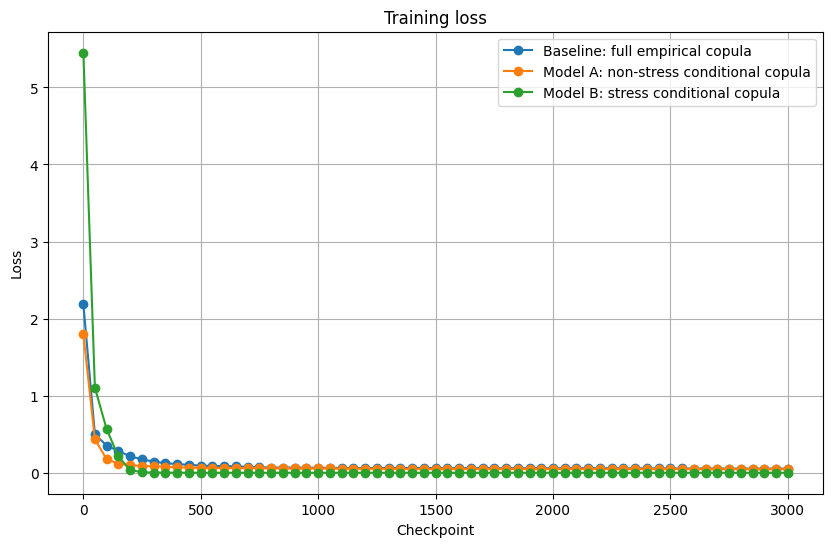

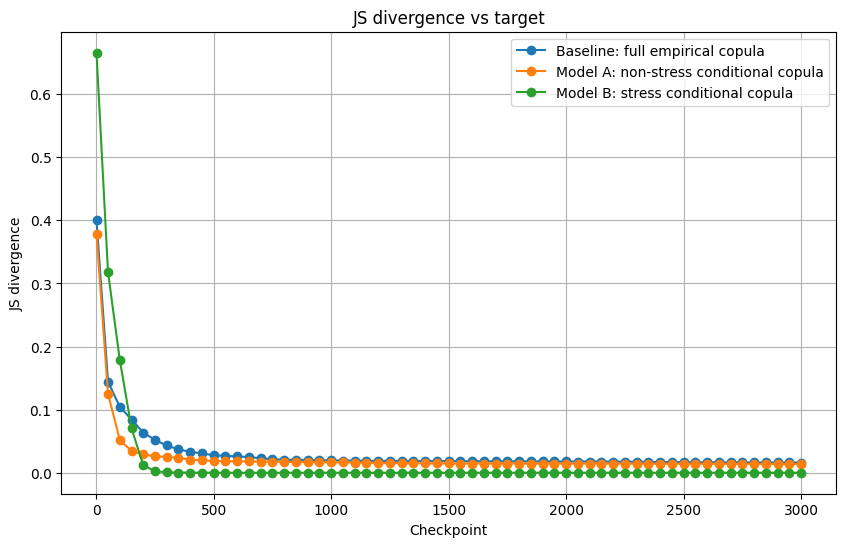

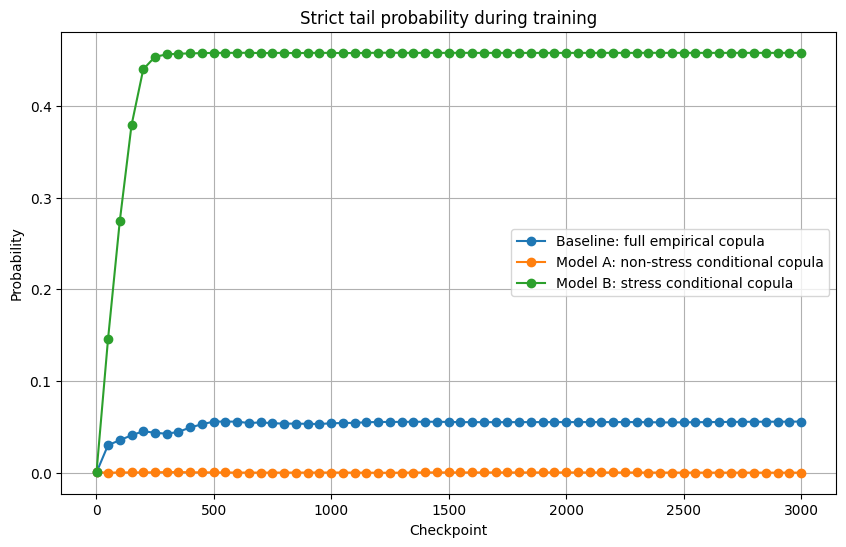

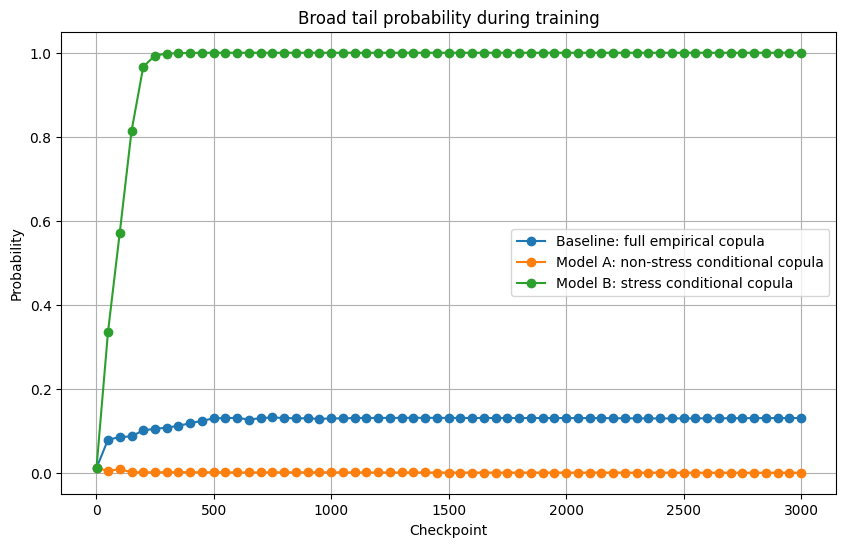

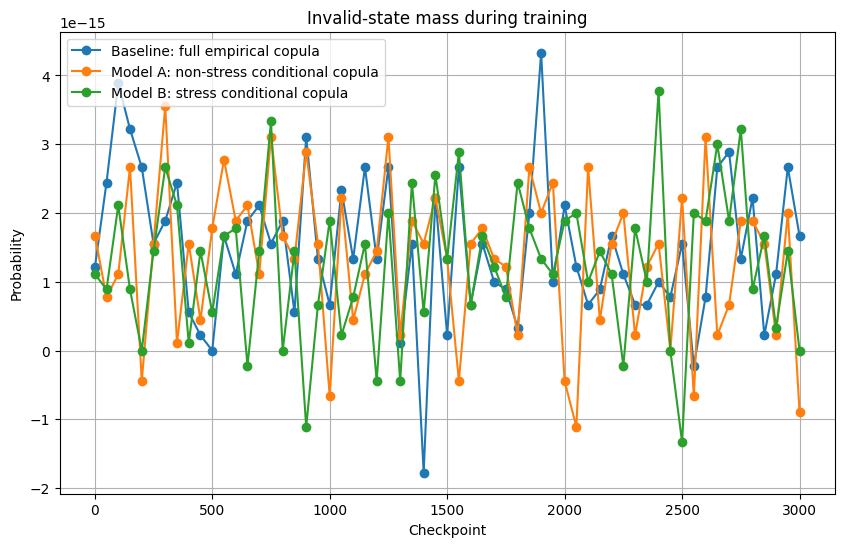

In [ ]:
# Section 6.1: Training diagnostics

for metric, title, ylabel in [
    ("loss", "Training loss", "Loss"),
    ("js_vs_target", "JS divergence vs target", "JS divergence"),
    ("strict_tail", "Strict tail probability during training", "Probability"),
    ("broad_tail", "Broad tail probability during training", "Probability"),
    ("invalid_mass", "Invalid-state mass during training", "Probability"),
]:
    plt.figure(figsize=(10, 6))
    for model_name, sub in history_df.groupby("model"):
        plt.plot(sub["epoch"], sub[metric], marker="o", label=model_name)
    plt.title(title)
    plt.xlabel("Checkpoint")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

In [ ]:
# Section 6.2: Detailed state comparison against the empirical full copula

compare_df = pd.DataFrame({
    "empirical_full": empirical_probs,
    "baseline_full_exact": full_model["exact_probs"],
    "regime_mixture_exact": mixture_exact_probs,
    "nonstress_exact": nonstress_model["exact_probs"],
    "stress_exact": stress_model["exact_probs"],
})

compare_df["abs_error_baseline_full"] = np.abs(compare_df["baseline_full_exact"] - compare_df["empirical_full"])
compare_df["abs_error_regime_mixture"] = np.abs(compare_df["regime_mixture_exact"] - compare_df["empirical_full"])

top_compare = compare_df.sort_values("empirical_full", ascending=False).head(25).copy()
top_compare["BBB_bin"] = [state_index_to_triplet(i, PHYSICAL_LEVELS_PER_ASSET)[0] for i in top_compare.index]
top_compare["BB_bin"]  = [state_index_to_triplet(i, PHYSICAL_LEVELS_PER_ASSET)[1] for i in top_compare.index]
top_compare["HY_bin"]  = [state_index_to_triplet(i, PHYSICAL_LEVELS_PER_ASSET)[2] for i in top_compare.index]
top_compare["is_invalid_state"] = (
    (top_compare["BBB_bin"] >= N_ACTIVE_BINS_PER_ASSET) |
    (top_compare["BB_bin"] >= N_ACTIVE_BINS_PER_ASSET) |
    (top_compare["HY_bin"] >= N_ACTIVE_BINS_PER_ASSET)
)

display(top_compare.reset_index(names="state"))

,state,empirical_full,baseline_full_exact,regime_mixture_exact,nonstress_exact,stress_exact,abs_error_baseline_full,abs_error_regime_mixture,BBB_bin,BB_bin,HY_bin,is_invalid_state
0,511,0.068661,0.055905,0.068854,0.000226,4.577650e-01,0.012756,0.000193,7,7,7,False
1,0,0.064093,0.053460,0.061085,0.071864,4.530035e-09,0.010633,0.003009,0,0,0,False
2,292,0.053927,0.056640,0.056878,0.066914,2.051885e-11,0.002713,0.002951,4,4,4,False
3,137,0.035656,0.036240,0.032619,0.038375,7.436716e-12,0.000584,0.003038,2,1,1,False
4,274,0.030352,0.032232,0.029998,0.035291,3.315522e-12,0.001880,0.000354,4,2,2,False
5,301,0.027700,0.028913,0.026637,0.031337,4.600124e-11,0.001213,0.001063,4,5,5,False
6,438,0.027258,0.025111,0.027328,0.000082,1.817309e-01,0.002147,0.000070,6,6,6,False
7,310,0.024459,0.024079,0.024187,0.028455,7.969740e-11,0.000380,0.000271,4,6,6,False
8,283,0.022690,0.019922,0.023810,0.028012,7.433215e-14,0.002768,0.001120,4,3,3,False
9,265,0.022543,0.022748,0.021706,0.025537,1.224578e-12,0.000204,0.000837,4,1,1,False


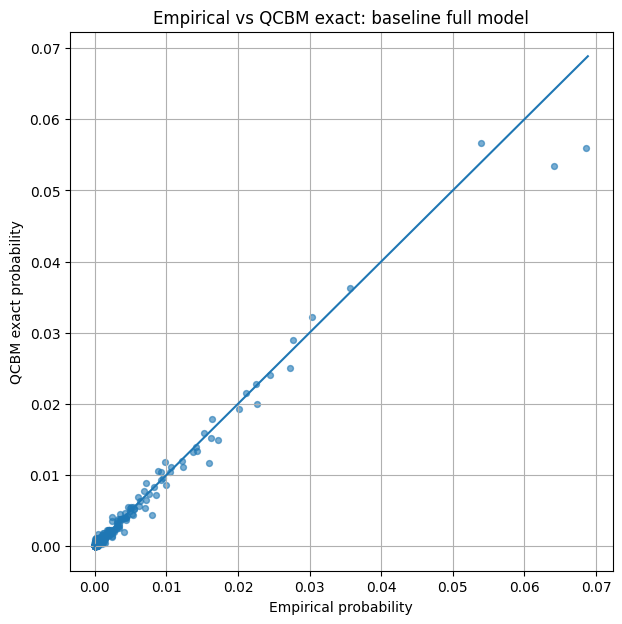

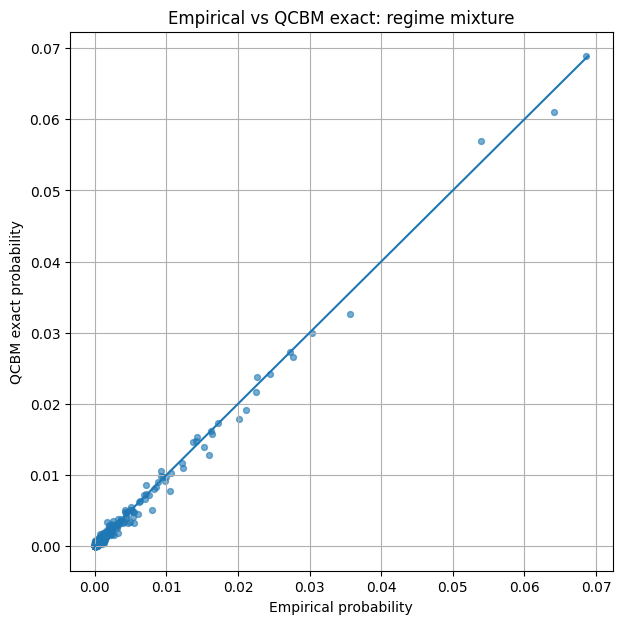

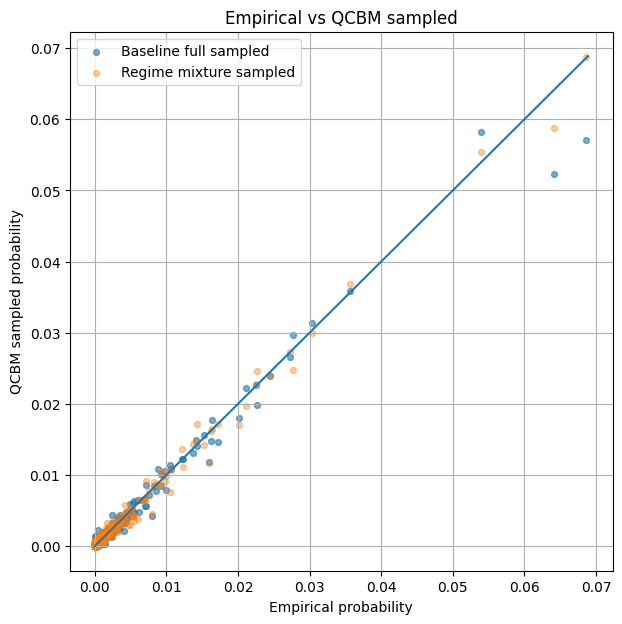

In [ ]:
# Section 6.3: Scatter comparisons against the empirical full copula

plot_max = max(
    empirical_probs.max(),
    full_model["exact_probs"].max(),
    mixture_exact_probs.max()
)

plt.figure(figsize=(7, 7))
plt.scatter(empirical_probs, full_model["exact_probs"], alpha=0.6, s=18)
plt.plot([0, plot_max], [0, plot_max])
plt.title("Empirical vs QCBM exact: baseline full model")
plt.xlabel("Empirical probability")
plt.ylabel("QCBM exact probability")
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(empirical_probs, mixture_exact_probs, alpha=0.6, s=18)
plt.plot([0, plot_max], [0, plot_max])
plt.title("Empirical vs QCBM exact: regime mixture")
plt.xlabel("Empirical probability")
plt.ylabel("QCBM exact probability")
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(empirical_probs, full_model["sampled_probs"], alpha=0.6, s=18, label="Baseline full sampled")
plt.scatter(empirical_probs, mixture_sampled_probs, alpha=0.4, s=18, label="Regime mixture sampled")
plt.plot([0, plot_max], [0, plot_max])
plt.title("Empirical vs QCBM sampled")
plt.xlabel("Empirical probability")
plt.ylabel("QCBM sampled probability")
plt.legend()
plt.show()

In [ ]:
# Section 6.4: Notebook interpretation summary

emp_strict = stress_probability_corner(
    empirical_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    STRICT_STRESS_BIN
)
emp_broad = stress_probability_corner(
    empirical_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    BROAD_STRESS_MIN_BIN
)
emp_invalid = invalid_state_mass(
    empirical_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET
)

baseline_strict = stress_probability_corner(
    full_model["exact_probs"],
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    STRICT_STRESS_BIN
)
baseline_broad = stress_probability_corner(
    full_model["exact_probs"],
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    BROAD_STRESS_MIN_BIN
)
baseline_invalid = invalid_state_mass(
    full_model["exact_probs"],
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET
)

mix_strict = stress_probability_corner(
    mixture_exact_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    STRICT_STRESS_BIN
)
mix_broad = stress_probability_corner(
    mixture_exact_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET,
    BROAD_STRESS_MIN_BIN
)
mix_invalid = invalid_state_mass(
    mixture_exact_probs,
    PHYSICAL_LEVELS_PER_ASSET,
    N_ACTIVE_BINS_PER_ASSET
)

stress_exact_js = js_divergence(stress_probs, stress_model["exact_probs"])
nonstress_exact_js = js_divergence(nonstress_probs, nonstress_model["exact_probs"])
baseline_full_js = js_divergence(empirical_probs, full_model["exact_probs"])
mix_full_js = js_divergence(empirical_probs, mixture_exact_probs)

print("Notebook interpretation")
print("=======================")
print(f"Active bins per asset:                     {N_ACTIVE_BINS_PER_ASSET}")
print(f"Physical levels per asset:                 {PHYSICAL_LEVELS_PER_ASSET}")
print(f"Physical QCBM states:                      {N_QCBM_STATES}")
print(f"Active empirical states:                   {N_ACTIVE_STATES}")
print()
print(f"Observations in full dataset:              {len(full_state_idx):,}")
print(f"Observations in non-stress subset:         {len(nonstress_state_idx):,}")
print(f"Observations in stress subset:             {len(stress_state_idx):,}")
print(f"Average observations per active state:     {len(full_state_idx) / N_ACTIVE_STATES:.2f}")
print(f"Stress regime frequency pi:                {PI_STRESS:.6f}")
print()
print("Full empirical copula target")
print(f"  Empirical strict stress probability:     {emp_strict:.6f}")
print(f"  Empirical broad stress probability:      {emp_broad:.6f}")
print(f"  Empirical invalid-state mass:            {emp_invalid:.6f}")
print()
print("Baseline single-model QCBM")
print(f"  QCBM exact strict stress probability:    {baseline_strict:.6f}")
print(f"  QCBM exact broad stress probability:     {baseline_broad:.6f}")
print(f"  QCBM invalid-state mass:                 {baseline_invalid:.6f}")
print(f"  JS vs full empirical target:             {baseline_full_js:.6f}")
print()
print("Regime-mixture QCBM")
print(f"  Mixture exact strict stress probability: {mix_strict:.6f}")
print(f"  Mixture exact broad stress probability:  {mix_broad:.6f}")
print(f"  Mixture invalid-state mass:              {mix_invalid:.6f}")
print(f"  JS vs full empirical target:             {mix_full_js:.6f}")
print()
print("Conditional regime fits")
print(f"  Model A non-stress JS vs target:         {nonstress_exact_js:.6f}")
print(f"  Model B stress JS vs target:             {stress_exact_js:.6f}")
print()
print("Interpretation:")
print("The notebook uses a fully aligned 8-bin discretization with 3 qubits per asset,")
print("so the empirical target and the QCBM both live on the same 512-state space.")
print()
print("The baseline model is a single QCBM fitted directly to the full empirical credit copula.")
print("The regime-mixture approach instead trains one QCBM on non-stress days and one QCBM on stress days,")
print("then recombines them with the empirical stress frequency.")
print()
print("This setup tests whether separating calm and stressed dependence structures improves tail calibration.")
print("If the regime-mixture model improves tail realism without sacrificing too much global fit quality,")
print("that supports the idea that credit dependence is structurally regime-dependent.")

Notebook interpretation
Active bins per asset:                     8
Physical levels per asset:                 8
Physical QCBM states:                      512
Active empirical states:                   512

Observations in full dataset:              6,787
Observations in non-stress subset:         5,769
Observations in stress subset:             1,018
Average observations per active state:     13.26
Stress regime frequency pi:                0.149993

Full empirical copula target
  Empirical strict stress probability:     0.068661
  Empirical broad stress probability:      0.149993
  Empirical invalid-state mass:            0.000000

Baseline single-model QCBM
  QCBM exact strict stress probability:    0.055905
  QCBM exact broad stress probability:     0.131107
  QCBM invalid-state mass:                 0.000000
  JS vs full empirical target:             0.016148

Regime-mixture QCBM
  Mixture exact strict stress probability: 0.068854
  Mixture exact broad stress probability:  0.150

,model,JS_vs_empirical,strict_tail,broad_tail
0,Empirical,0.000000,0.068661,0.149993
1,Baseline QCBM,0.016148,0.055905,0.131107
2,Regime-mixture QCBM,0.011651,0.068854,0.150657


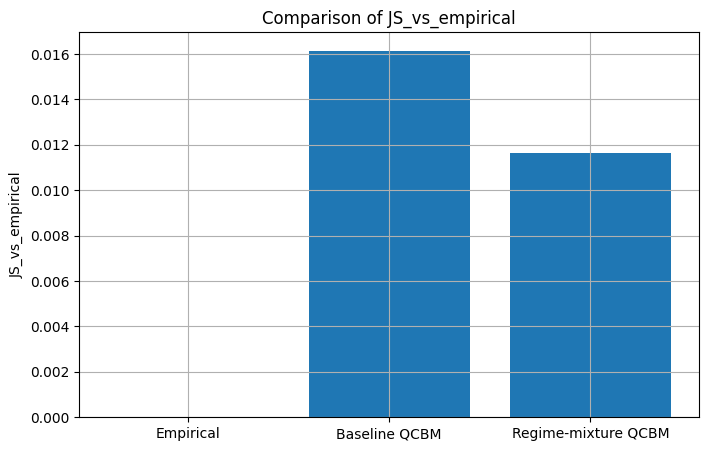

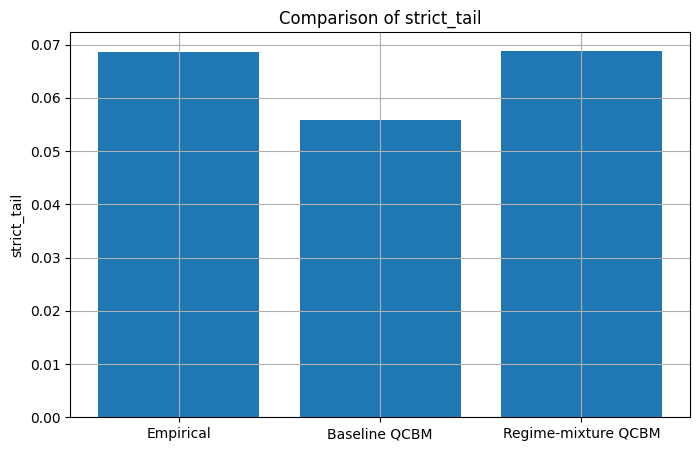

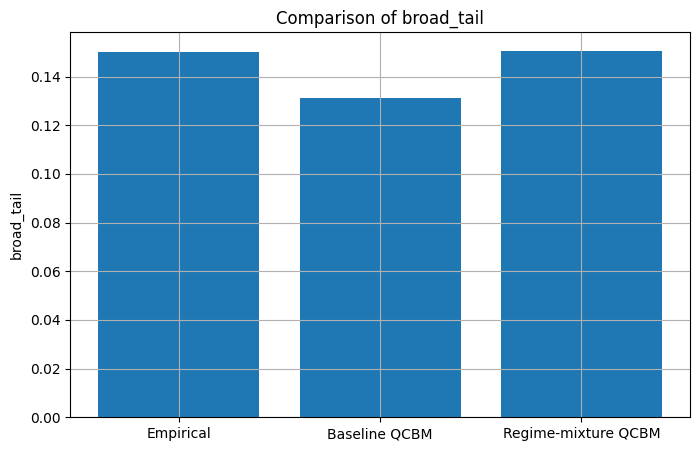

In [ ]:
# Section 6.5: Compact comparison of headline metrics

plot_df = pd.DataFrame([
    {
        "model": "Empirical",
        "JS_vs_empirical": 0.0,
        "strict_tail": stress_probability_corner(
            empirical_probs, PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, STRICT_STRESS_BIN
        ),
        "broad_tail": stress_probability_corner(
            empirical_probs, PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, BROAD_STRESS_MIN_BIN
        ),
    },
    {
        "model": "Baseline QCBM",
        "JS_vs_empirical": js_divergence(empirical_probs, full_model["exact_probs"]),
        "strict_tail": stress_probability_corner(
            full_model["exact_probs"], PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, STRICT_STRESS_BIN
        ),
        "broad_tail": stress_probability_corner(
            full_model["exact_probs"], PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, BROAD_STRESS_MIN_BIN
        ),
    },
    {
        "model": "Regime-mixture QCBM",
        "JS_vs_empirical": js_divergence(empirical_probs, mixture_exact_probs),
        "strict_tail": stress_probability_corner(
            mixture_exact_probs, PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, STRICT_STRESS_BIN
        ),
        "broad_tail": stress_probability_corner(
            mixture_exact_probs, PHYSICAL_LEVELS_PER_ASSET, N_ACTIVE_BINS_PER_ASSET, BROAD_STRESS_MIN_BIN
        ),
    },
])

display(plot_df)

metrics = ["JS_vs_empirical", "strict_tail", "broad_tail"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(plot_df["model"], plot_df[metric])
    plt.title(f"Comparison of {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=0)
    plt.show()

,BBB_bin,BB_bin,HY_bin,empirical,baseline_qcbm,regime_mixture_qcbm
0,6,6,6,0.027258,0.025111,0.027328
1,6,6,7,0.002210,0.001764,0.002241
2,6,7,6,0.006336,0.006386,0.006341
3,6,7,7,0.017239,0.014971,0.017258
4,7,6,6,0.016207,0.015164,0.016256
5,7,6,7,0.004862,0.005319,0.005045
6,7,7,6,0.007220,0.006486,0.007335
7,7,7,7,0.068661,0.055905,0.068854


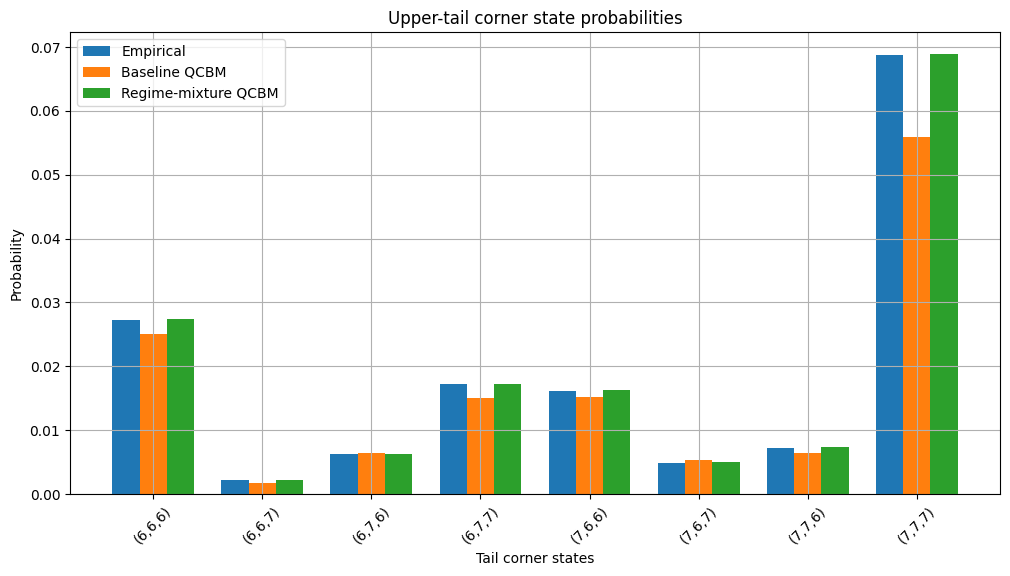

In [ ]:
# Section 6.6: Explicit upper-tail 2x2x2 corner comparison

def tail_corner_table(prob_vec, base_dim, broad_min_bin):
    rows = []
    for b1 in range(broad_min_bin, base_dim):
        for b2 in range(broad_min_bin, base_dim):
            for b3 in range(broad_min_bin, base_dim):
                idx = b1 * (base_dim ** 2) + b2 * base_dim + b3
                rows.append({
                    "BBB_bin": b1,
                    "BB_bin": b2,
                    "HY_bin": b3,
                    "probability": prob_vec[idx]
                })
    return pd.DataFrame(rows)


emp_tail_df = tail_corner_table(empirical_probs, PHYSICAL_LEVELS_PER_ASSET, BROAD_STRESS_MIN_BIN)
base_tail_df = tail_corner_table(full_model["exact_probs"], PHYSICAL_LEVELS_PER_ASSET, BROAD_STRESS_MIN_BIN)
mix_tail_df = tail_corner_table(mixture_exact_probs, PHYSICAL_LEVELS_PER_ASSET, BROAD_STRESS_MIN_BIN)

tail_compare = emp_tail_df.copy()
tail_compare = tail_compare.rename(columns={"probability": "empirical"})
tail_compare["baseline_qcbm"] = base_tail_df["probability"].values
tail_compare["regime_mixture_qcbm"] = mix_tail_df["probability"].values

display(tail_compare)

tail_compare["state_label"] = (
    "("
    + tail_compare["BBB_bin"].astype(str) + ","
    + tail_compare["BB_bin"].astype(str) + ","
    + tail_compare["HY_bin"].astype(str) + ")"
)

x = np.arange(len(tail_compare))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, tail_compare["empirical"], width=width, label="Empirical")
plt.bar(x, tail_compare["baseline_qcbm"], width=width, label="Baseline QCBM")
plt.bar(x + width, tail_compare["regime_mixture_qcbm"], width=width, label="Regime-mixture QCBM")
plt.xticks(x, tail_compare["state_label"], rotation=45)
plt.title("Upper-tail corner state probabilities")
plt.xlabel("Tail corner states")
plt.ylabel("Probability")
plt.legend()
plt.show()

## Visual diagnostics

The next plots show how the baseline and regime-mixture QCBMs compare with the empirical copula distribution both locally and across the full 3D grid.

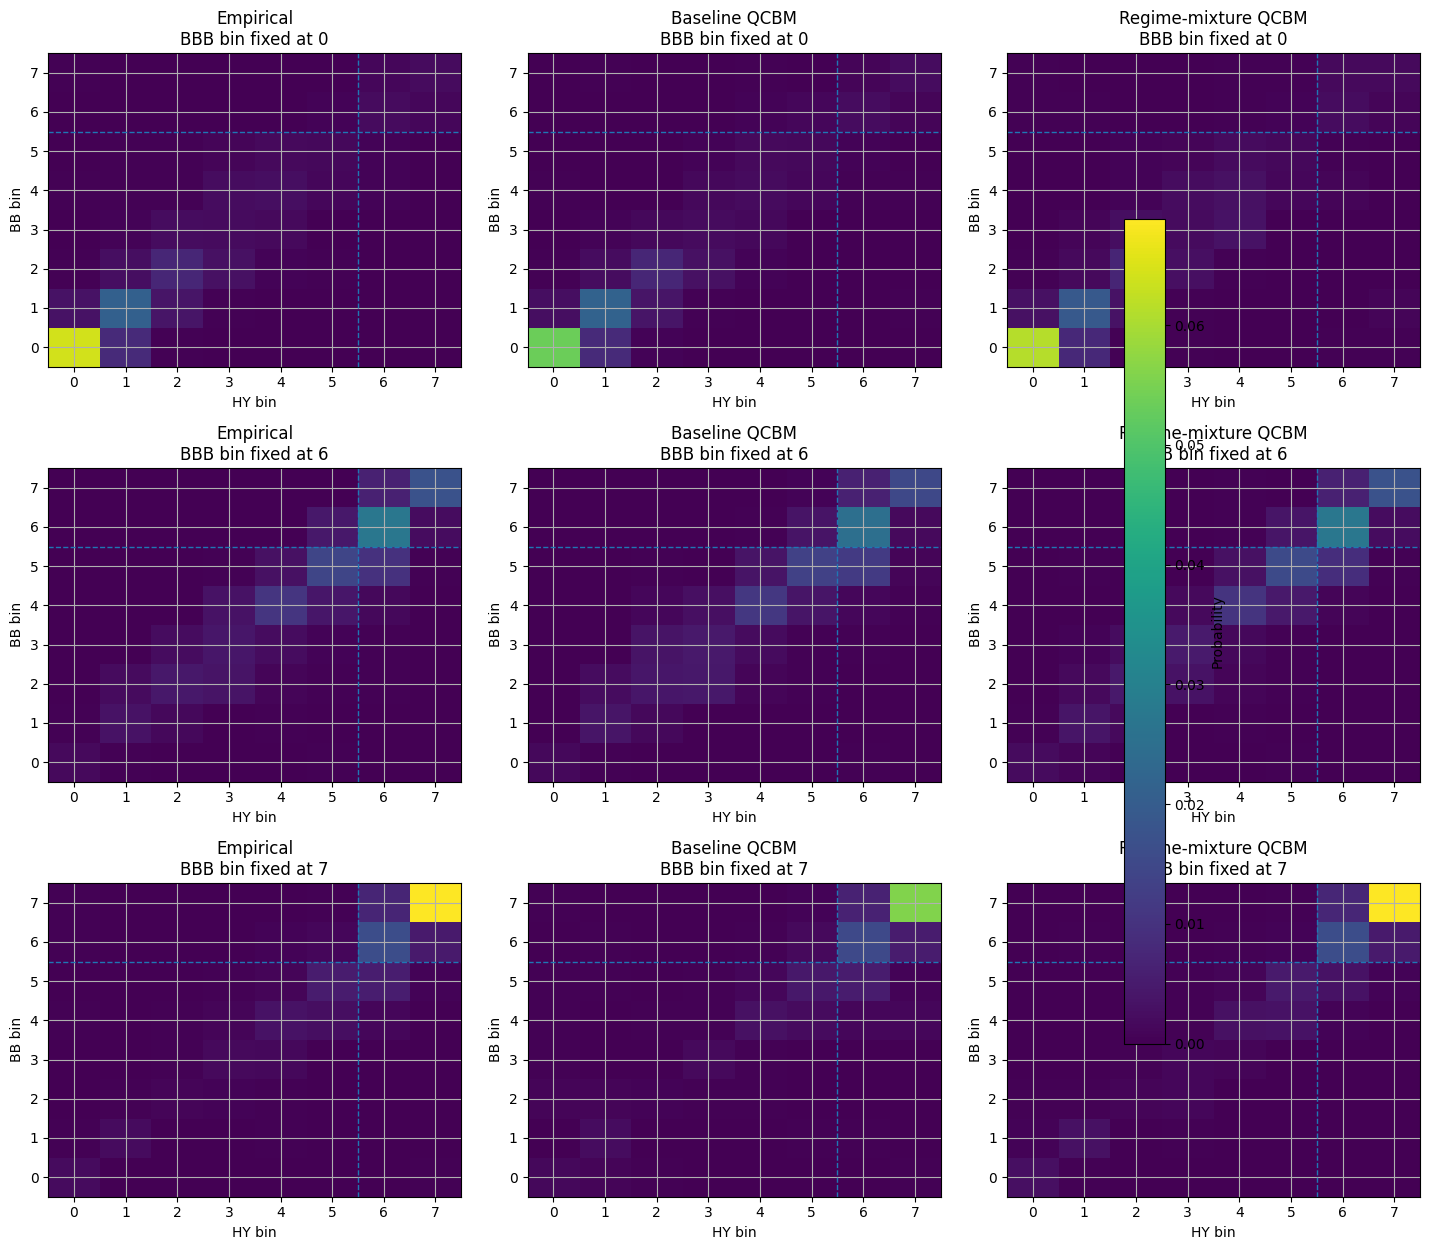

In [ ]:
# Section 7: Heatmap comparison for selected BBB slices

def plot_slice_heatmaps(empirical_probs, baseline_probs, mixture_probs, base_dim, fixed_bbb_bins):
    emp_cube = probs_to_cube(empirical_probs, base_dim)
    base_cube = probs_to_cube(baseline_probs, base_dim)
    mix_cube = probs_to_cube(mixture_probs, base_dim)

    models = [
        ("Empirical", emp_cube),
        ("Baseline QCBM", base_cube),
        ("Regime-mixture QCBM", mix_cube),
    ]

    n_rows = len(fixed_bbb_bins)
    n_cols = len(models)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 4.2 * n_rows))

    if n_rows == 1:
        axes = np.array([axes])

    vmax = max(emp_cube.max(), base_cube.max(), mix_cube.max())

    for row_idx, bbb_bin in enumerate(fixed_bbb_bins):
        for col_idx, (title, cube) in enumerate(models):
            ax = axes[row_idx, col_idx]

            heat = cube[bbb_bin, :, :]

            im = ax.imshow(
                heat,
                origin="lower",
                aspect="auto",
                vmin=0,
                vmax=vmax
            )

            ax.set_title(f"{title}\nBBB bin fixed at {bbb_bin}")
            ax.set_xlabel("HY bin")
            ax.set_ylabel("BB bin")

            ax.set_xticks(range(base_dim))
            ax.set_yticks(range(base_dim))

            ax.axhline(BROAD_STRESS_MIN_BIN - 0.5, linestyle="--", linewidth=1)
            ax.axvline(BROAD_STRESS_MIN_BIN - 0.5, linestyle="--", linewidth=1)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label("Probability")

    plt.tight_layout()
    plt.show()


plot_slice_heatmaps(
    empirical_probs=empirical_probs,
    baseline_probs=full_model["exact_probs"],
    mixture_probs=mixture_exact_probs,
    base_dim=PHYSICAL_LEVELS_PER_ASSET,
    fixed_bbb_bins=[0, 6, 7]
)

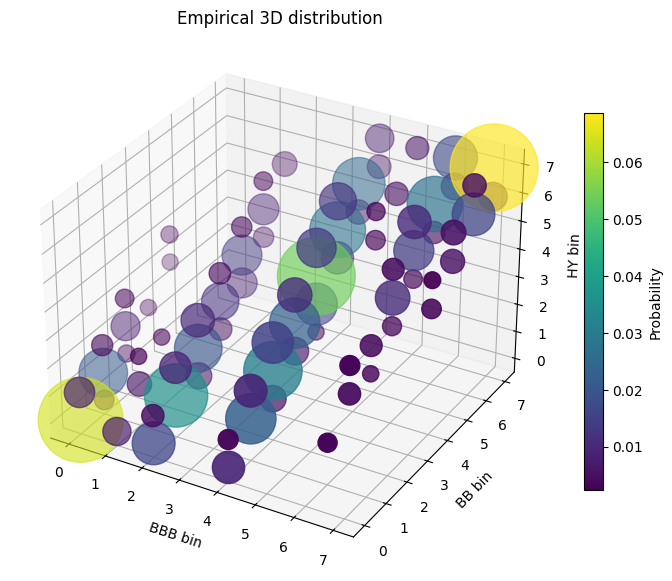

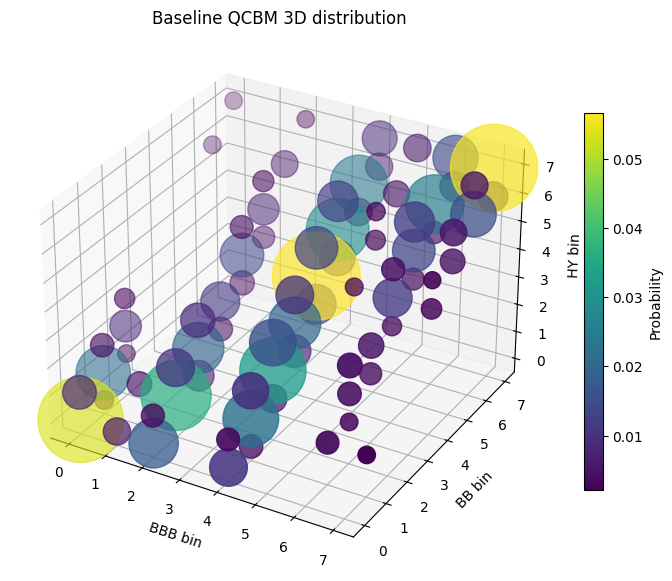

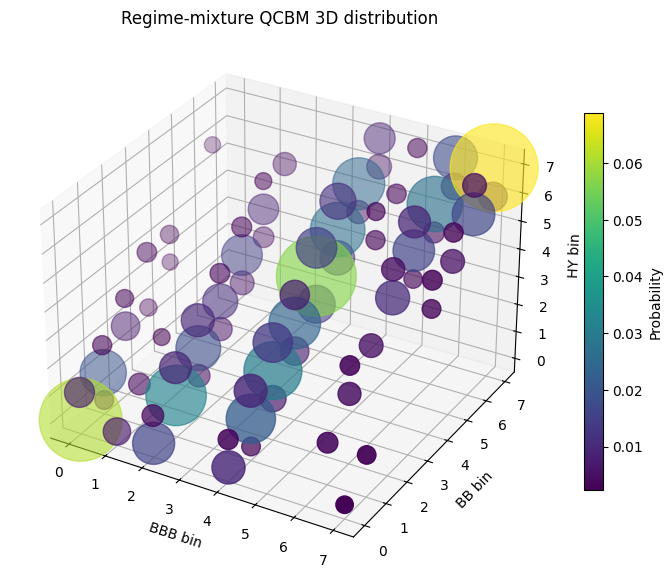

In [ ]:
# Section 7.1: 3D scatter plot of the full 8x8x8 distribution

from mpl_toolkits.mplot3d import Axes3D


def state_probs_to_xyz(prob_vec, base_dim):
    rows = []
    for idx, p in enumerate(prob_vec):
        b1, b2, b3 = state_index_to_triplet(idx, base_dim)
        rows.append((b1, b2, b3, p))
    df = pd.DataFrame(rows, columns=["BBB_bin", "BB_bin", "HY_bin", "probability"])
    return df


def plot_3d_distribution(prob_vec, title, base_dim=8, prob_threshold=0.001, top_n=None):
    df = state_probs_to_xyz(prob_vec, base_dim)

    if top_n is not None:
        df = df.sort_values("probability", ascending=False).head(top_n).copy()
    else:
        df = df[df["probability"] >= prob_threshold].copy()

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    sizes = 4000 * df["probability"].values / df["probability"].max()
    sc = ax.scatter(
        df["BBB_bin"],
        df["BB_bin"],
        df["HY_bin"],
        s=sizes,
        c=df["probability"],
        depthshade=True
    )

    ax.set_title(title)
    ax.set_xlabel("BBB bin")
    ax.set_ylabel("BB bin")
    ax.set_zlabel("HY bin")

    ax.set_xticks(range(base_dim))
    ax.set_yticks(range(base_dim))
    ax.set_zticks(range(base_dim))

    plt.colorbar(sc, ax=ax, shrink=0.7, label="Probability")
    plt.show()


plot_3d_distribution(empirical_probs, "Empirical 3D distribution", base_dim=PHYSICAL_LEVELS_PER_ASSET, top_n=80)
plot_3d_distribution(full_model["exact_probs"], "Baseline QCBM 3D distribution", base_dim=PHYSICAL_LEVELS_PER_ASSET, top_n=80)
plot_3d_distribution(mixture_exact_probs, "Regime-mixture QCBM 3D distribution", base_dim=PHYSICAL_LEVELS_PER_ASSET, top_n=80)

## Conclusion

In this notebook, a regime-mixture QCBM provides a materially better fit to the most extreme joint tail state than a single baseline QCBM trained on the full empirical distribution.

This suggests that regime-aware quantum generative modeling may be a useful direction for dependency-aware stress scenario generation in credit risk, while still remaining a simulator-based proof of concept.

**Created by [qubit-lab.ch](https://qubit-lab.ch)**  
© 2026 [qubit-lab.ch](https://qubit-lab.ch). All rights reserved.  
For the accompanying explanatory video, additional notebooks, and legal information, visit **[qubit-lab.ch](https://qubit-lab.ch)** and **[qubit-lab.ch/legal](https://qubit-lab.ch/legal)**.